In [1]:
from dotenv import load_dotenv
load_dotenv()

True

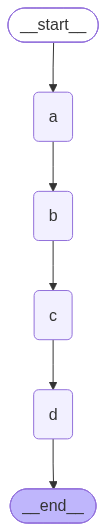

In [2]:
from IPython.display import Image, display

from typing import Any
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    state: list


def create_node_fn(node_secret: str):
    """Create a node function that adds its secret to the state."""
    def node_function(state):
        print(f"Adding {node_secret} to {state['state']}")
        return {"state": [node_secret]}
    return node_function


# Add nodes
builder = StateGraph(State)

builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow - linear sequence
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
result = graph.invoke({"state": []})

print(f"Final state: {result['state']}")

result

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm B"]
Adding I'm D to ["I'm C"]
Final state: ["I'm D"]


{'state': ["I'm D"]}

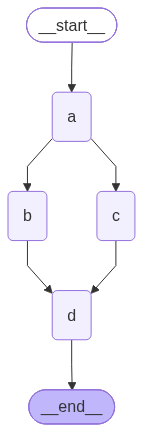

In [4]:
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow - fan-out from a to b and c, then fan-in to d
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
An error occurred: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


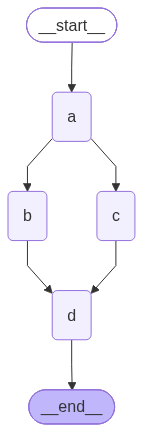

In [6]:
import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    state: Annotated[list, operator.add]

# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm D"]}

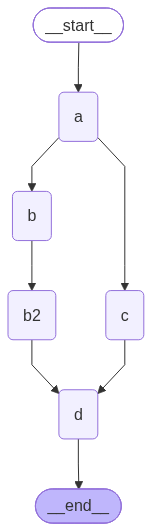

In [8]:
builder = StateGraph(State)

# Initialize each node with node_secret
builder.add_node("a", create_node_fn("I'm A"))
builder.add_node("b", create_node_fn("I'm B"))
builder.add_node("b2", create_node_fn("I'm B2"))
builder.add_node("c", create_node_fn("I'm C"))
builder.add_node("d", create_node_fn("I'm D"))

# Flow
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")  # Both b2 and c must complete before d
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI()

In [11]:
class State(TypedDict):
    order_id: str
    answer: str
    context: Annotated[list, operator.add]

In [12]:
import time
from langchain_core.messages import HumanMessage, SystemMessage

ORDERS = {
    "A1001": "Customer: Priya Shah. Item: TrailBlazer 30L backpack. Amount: Rs 4299. Payment: paid.",
    "A1002": "Customer: Arjun Mehta. Item: Noise-cancelling headphones. Amount: Rs 7999. Payment: paid.",
}

SHIPMENTS = {
    "A1001": "Carrier: BlueDart. Status: in transit. Last scan: Mumbai hub. ETA: 26 Sep 2026.",
    "A1002": "Carrier: Delhivery. Status: delivered. Delivered on: 20 Sep 2026. Signed by: reception.",
}

def lookup_order(state):
    """Read the order row. The sleep stands in for a slow database call."""
    order_id = state["order_id"]
    print(f"[{time.strftime('%H:%M:%S')}] lookup_order started for {order_id}")
    time.sleep(2)
    record = ORDERS.get(order_id, f"No order found for {order_id}.")
    print(f"[{time.strftime('%H:%M:%S')}] lookup_order finished")
    return {"context": [f"Order record: {record}"]}

def lookup_shipping(state):
    """Read the shipment row. Runs at the same time as lookup_order."""
    order_id = state["order_id"]
    print(f"[{time.strftime('%H:%M:%S')}] lookup_shipping started for {order_id}")
    time.sleep(2)
    record = SHIPMENTS.get(order_id, f"No shipment found for {order_id}.")
    print(f"[{time.strftime('%H:%M:%S')}] lookup_shipping finished")
    return {"context": [f"Shipping record: {record}"]}

def generate_answer(state):
    """Write a customer update after both lookups have finished."""
    context = "\n\n".join(state["context"])
    order_id = state["order_id"]
    answer_instructions = (
        f"Write a short customer-support update for order {order_id}. "
        f"Use only this context:\n{context}"
    )
    answer = llm.invoke(
        [SystemMessage(content=answer_instructions)]
        + [HumanMessage(content="Write the update.")]
    )
    return {"answer": answer}

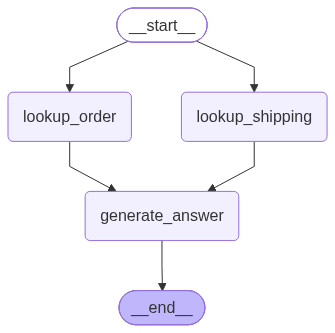

In [13]:
# Add nodes
builder = StateGraph(State)

builder.add_node("lookup_order", lookup_order)
builder.add_node("lookup_shipping", lookup_shipping)
builder.add_node("generate_answer", generate_answer)

# Both lookups start together, then fan in to the answer node
builder.add_edge(START, "lookup_order")
builder.add_edge(START, "lookup_shipping")
builder.add_edge("lookup_order", "generate_answer")
builder.add_edge("lookup_shipping", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
started = time.perf_counter()
result = graph.invoke({"order_id": "A1001", "context": []})
print(f"Total seconds: {time.perf_counter() - started:.1f}")
result["answer"].content

[13:19:05] lookup_order started for A1001
[13:19:05] lookup_shipping started for A1001
[13:19:07] lookup_order finished
[13:19:07] lookup_shipping finished
Total seconds: 5.7


"Update for order A1001:\nOrder A1001 for Priya Shah's TrailBlazer 30L backpack, priced at Rs 4299, has been successfully paid for. The shipping is in transit with carrier BlueDart, with the last scan showing at the Mumbai hub. The estimated time of arrival (ETA) for delivery is 26 Sep 2026."